Notebook Para Análise Steam

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("steam.csv")


1- Identifica a média de avaliações positivas dos gêneros e qual o gênero mais bem avaliado:
  - Primeiro: Análise bruta
  - Segundo: Análise com filtros para gêneros com menos de 10 aparições em jogos

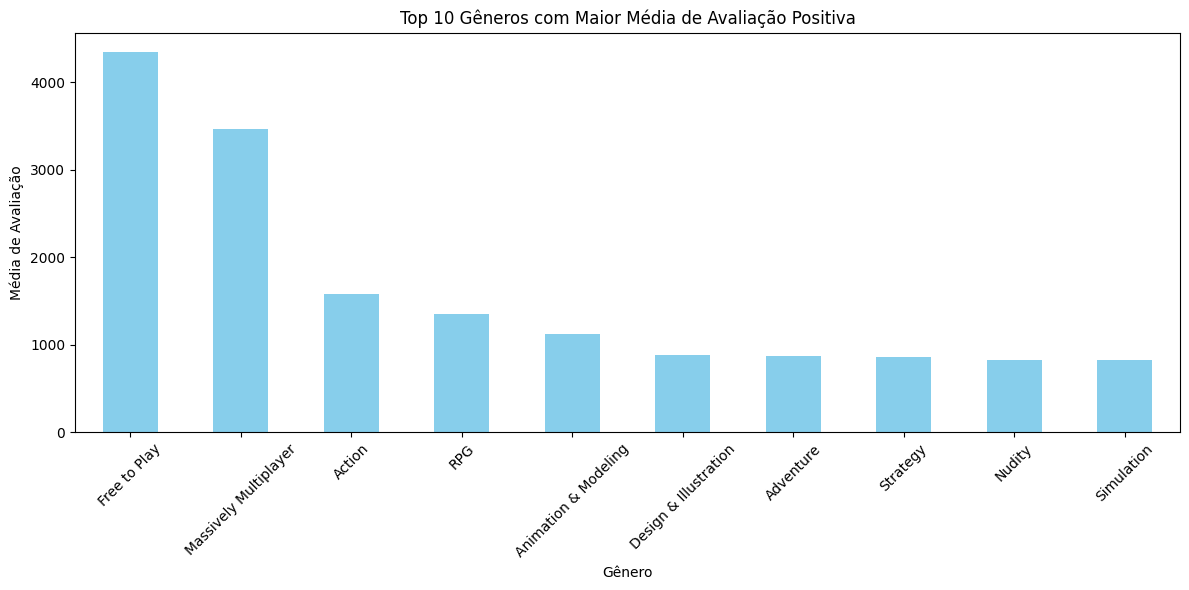

In [4]:

df['genres'] = df['genres'].str.split(";")
df_exploded = df.explode('genres')
df_exploded.groupby('genres')['positive_ratings'].mean().sort_values(ascending=False)

genre_avg = df_exploded.groupby('genres')['positive_ratings'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
genre_avg.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Gêneros com Maior Média de Avaliação Positiva')
plt.ylabel('Média de Avaliação')
plt.xlabel('Gênero')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"Free To Play" lidera com uma média de 4346.627347

C:\Users\Lucass\AppData\Local\Temp\ipykernel_1124\3485738171.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='genres', y='positive_ratings', palette='viridis')


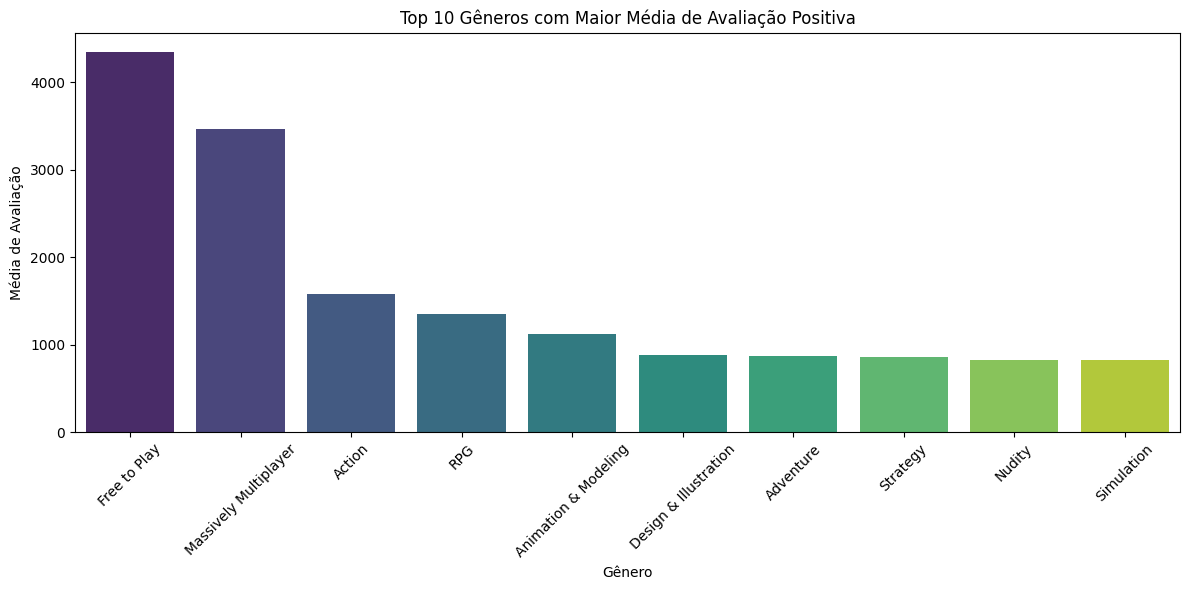

In [5]:
genre_counts = df_exploded['genres'].value_counts()
genres_small = genre_counts[genre_counts >= 10].index
filtered = df_exploded[df_exploded['genres'].isin(genres_small)]
filtered.groupby('genres')['positive_ratings'].mean().sort_values(ascending=False)

top_genres = genre_avg = df_exploded.groupby('genres')['positive_ratings'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_genres, x='genres', y='positive_ratings', palette='viridis')
plt.title('Top 10 Gêneros com Maior Média de Avaliação Positiva')
plt.ylabel('Média de Avaliação')
plt.xlabel('Gênero')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


2- Identifica quais gêneros têm mais avaliações positivas em média proporcionalmente ao total de avaliações

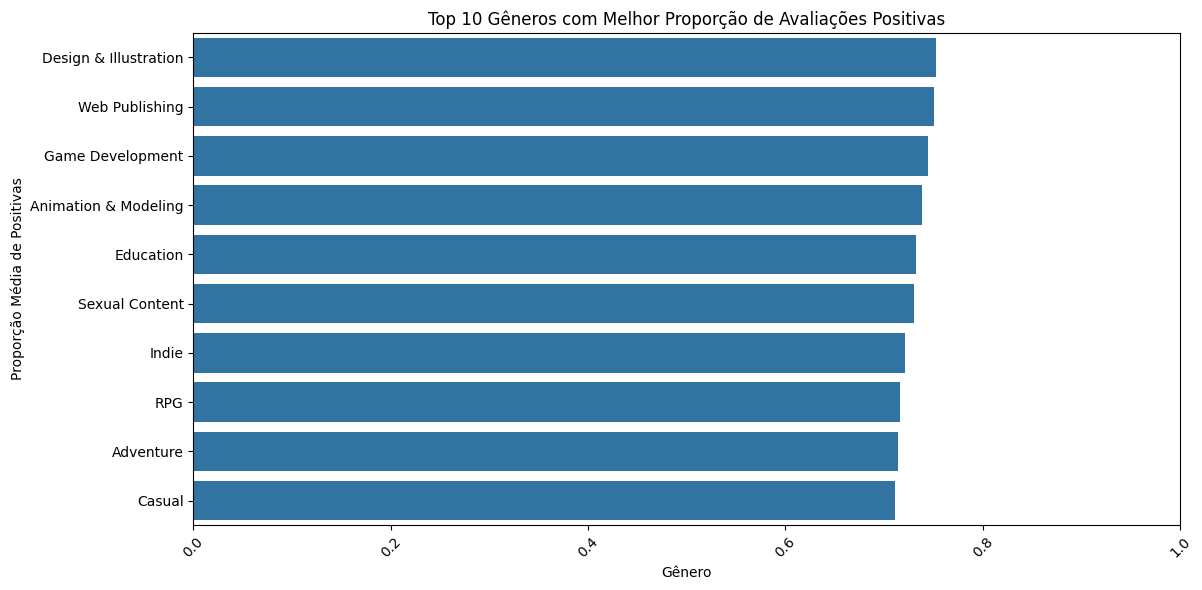

In [20]:
df['total_ratings'] = df['positive_ratings'] + df['negative_ratings']
df['positive_results'] = df['positive_ratings'] / df['total_ratings']

df['genres'] = df['genres'].str.split(";")
df_exploded = df.explode('genres')

genre_counts = df_exploded['genres'].value_counts()
genres_small = genre_counts[genre_counts >= 10].index
filtered = df_exploded[df_exploded['genres'].isin(genres_small)]
filtered.groupby('genres')['positive_results'].mean().sort_values(ascending=False)


genre_result = df_exploded.groupby('genres')['positive_results'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='positive_results', y='genres', data=genre_result)
plt.title('Top 10 Gêneros com Melhor Proporção de Avaliações Positivas')
plt.ylabel('Proporção Média de Positivas')
plt.xlabel('Gênero')
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlim(0,1)
plt.show()

3 - identifica os 5 jogos mais bem avaliados e os 5 mais mal avaliados

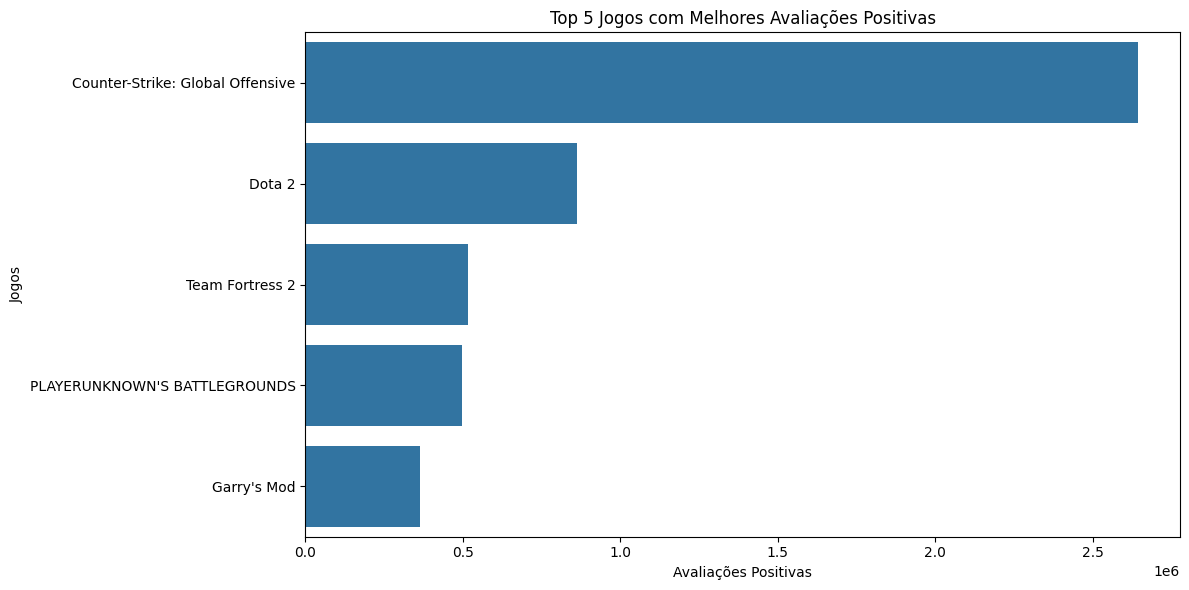

C:\Users\Lucass\AppData\Local\Temp\ipykernel_1124\3926450034.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='negative_ratings', y='name', data=top_negativos, palette='crest')


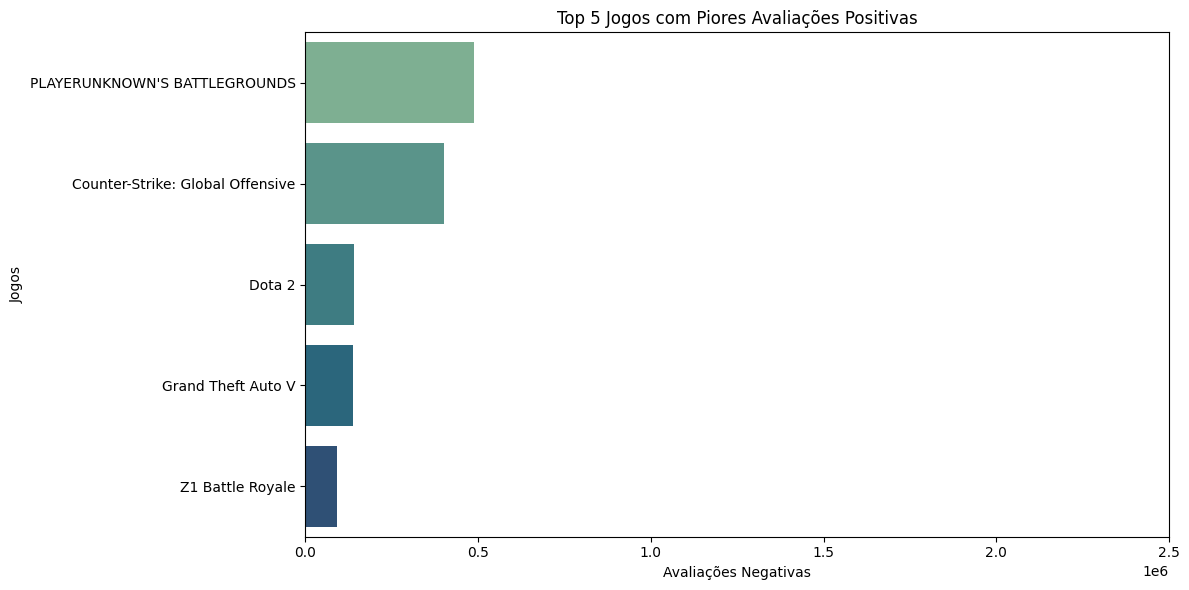

In [8]:
top_positivos = df[['name', 'positive_ratings']].sort_values(by='positive_ratings', ascending=False).head(5)

plt.figure(figsize=(12,6))
sns.barplot(x='positive_ratings', y='name', data=top_positivos)
plt.title('Top 5 Jogos com Melhores Avaliações Positivas')
plt.ylabel('Jogos')
plt.xlabel('Avaliações Positivas')
plt.tight_layout()
plt.show()


top_negativos = df[['name', 'negative_ratings']].sort_values(by='negative_ratings', ascending=False).head(5)

plt.figure(figsize=(12,6))
sns.barplot(x='negative_ratings', y='name', data=top_negativos, palette='crest')
plt.title('Top 5 Jogos com Piores Avaliações Positivas')
plt.ylabel('Jogos')
plt.xlabel('Avaliações Negativas')
plt.xlim(0,2500000)
plt.tight_layout()
plt.show()
